In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from params import conn_features
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

import seaborn as sns

PATH = "/Users/vladimiromelyusik/processed_data.csv"

from neuro_spec import ANAT_COLS, BOLD_COLS, DMN, SN, ECN
print(len(set(DMN) | set(SN) | set(ECN)))

19


In [30]:
def jaccard_similarity(A, B):
    return len(A & B) / len(A | B)

def with_network_similarity(found_regions, network):
    return len(found_regions & network) / len(network)

In [3]:
def get_similarity_matrixes(data_subject):

    data_subject = data_subject.sort_values("ROI")
    assert len(data_subject) == 68

    # -- Anatomical similarity
    anat_data = data_subject[ANAT_COLS].to_numpy()
    
    # Z-score across regions
    anat_data = (anat_data - np.mean(anat_data, axis = 0)) / np.std(anat_data, axis = 0)

    # Cross-correlate
    AS_matrix = np.corrcoef(anat_data)

    # -- Functional connectivity
    bold_data = data_subject[BOLD_COLS].dropna(axis = 1).to_numpy()
    
    # Z-score across time (but not per region)
    bold_data = (bold_data - np.mean(bold_data, axis = 1, keepdims = True)) / np.std(bold_data, axis = 1, keepdims = True)
    
    # Cross-correlate
    FC_matrix = np.corrcoef(bold_data)

    return AS_matrix, FC_matrix

In [4]:
data = pd.read_csv(PATH)
data.head()

,subject,ROI,NumVert,SurfArea_mm2,GrayVol_mm3,ThickAvg_mm,ThickStd_mm,MeanCurv_mm-1,GausCurv_mm-2,FoldInd,...,ts_710,ts_711,ts_712,ts_713,ts_714,ts_715,ts_716,ts_717,ts_718,ts_719
0,1005,bankssts-lh,1559,1074,2704,2.654,0.475,0.096,0.016,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1005,bankssts-rh,1116,815,2039,2.705,0.490,0.098,0.013,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1005,caudalanteriorcingulate-lh,909,608,1722,2.317,0.765,0.116,0.014,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1005,caudalanteriorcingulate-rh,911,649,1656,2.305,0.598,0.141,0.017,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1005,caudalmiddlefrontal-lh,3108,2184,6452,2.691,0.507,0.117,0.023,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
AS_full = []
FC_full = []
target = []

for subject in data["subject"].unique():

    target_value = data[data["subject"] == subject]["FTND"].iloc[0]
    if pd.isna(target_value): continue

    AS_matrix, FC_matrix = get_similarity_matrixes(data[data["subject"] == subject])

    AS_full.append(AS_matrix[np.triu_indices(68, k = 1)])
    FC_full.append(FC_matrix[np.triu_indices(68, k = 1)])
    target.append(int(target_value))

AS_full = np.array(AS_full)
FC_full = np.array(FC_full)
target = np.array(target)

assert len(AS_full) == len(FC_full) == 276

#### Spearman correlation

In [6]:
corr_result = []

for feature_idx in range(2278):
    rho, p = spearmanr(FC_full[:, feature_idx], target)
    corr_result.append((rho, p))

corr_result = pd.DataFrame(corr_result, columns = ["rho", "p"])
corr_result["feature"] = conn_features()
corr_result["abs_rho"] = np.abs(corr_result["rho"])

corr_result = corr_result.sort_values(by = "abs_rho", ascending = False).reset_index(drop = True)
corr_result["p_adj"] = multipletests(corr_result["p"], alpha = 0.05, method = "fdr_bh")[1]

In [47]:
corr_result[corr_result["p_adj"] < 0.05]["feature"]

Series([], Name: feature, dtype: object)

#### K-Best features based on Mutual information

In [33]:
result = []

for matrix_id, matrix in enumerate([AS_full, FC_full]):
    for k in range(10, 100, 10):
        selector = SelectKBest(mutual_info_regression, k = k)
        selector.fit(matrix, target)

        regions = []
        for region_pair in np.array(conn_features())[selector.get_support()]:
            regions.append(f"{region_pair.split('-')[0]}")
            regions.append(f"{region_pair.split('-')[2]}")
        
        # Estimate similarities
        matrix_name = "AS" if matrix_id == 0 else "FC"

        out = [matrix_name, k]
        for network_to_check in [DMN, SN, ECN]:
            out.append(jaccard_similarity(set(regions), set(network_to_check)))

        for network_to_check in [DMN, SN, ECN]:
            out.append(with_network_similarity(set(regions), set(network_to_check)))
        
        result.append(out)

result = pd.DataFrame(result, columns = ["matrix", "k", "J_DMN", "J_SN", "J_ECN", "with_DMN", "with_SN", "with_ECN"])
result.head(2)

,matrix,k,J_DMN,J_SN,J_ECN,with_DMN,with_SN,with_ECN
0,AS,10,0.285714,0.250000,0.200000,0.50,0.8,0.444444
1,AS,20,0.333333,0.208333,0.222222,0.75,1.0,0.666667


In [51]:
result

,matrix,k,J_DMN,J_SN,J_ECN,with_DMN,with_SN,with_ECN
0,AS,10,0.285714,0.250000,0.200000,0.500000,0.8,0.444444
1,AS,20,0.333333,0.208333,0.222222,0.750000,1.0,0.666667
2,AS,30,0.322581,0.172414,0.225806,0.833333,1.0,0.777778
3,AS,40,0.303030,0.161290,0.212121,0.833333,1.0,0.777778
4,AS,50,0.285714,0.151515,0.235294,0.833333,1.0,0.888889
5,AS,60,0.285714,0.151515,0.235294,0.833333,1.0,0.888889
6,AS,70,0.314286,0.147059,0.228571,0.916667,1.0,0.888889
7,AS,80,0.285714,0.151515,0.235294,0.833333,1.0,0.888889
8,AS,90,0.314286,0.147059,0.228571,0.916667,1.0,0.888889
9,FC,10,0.190476,0.125000,0.466667,0.333333,0.4,0.777778


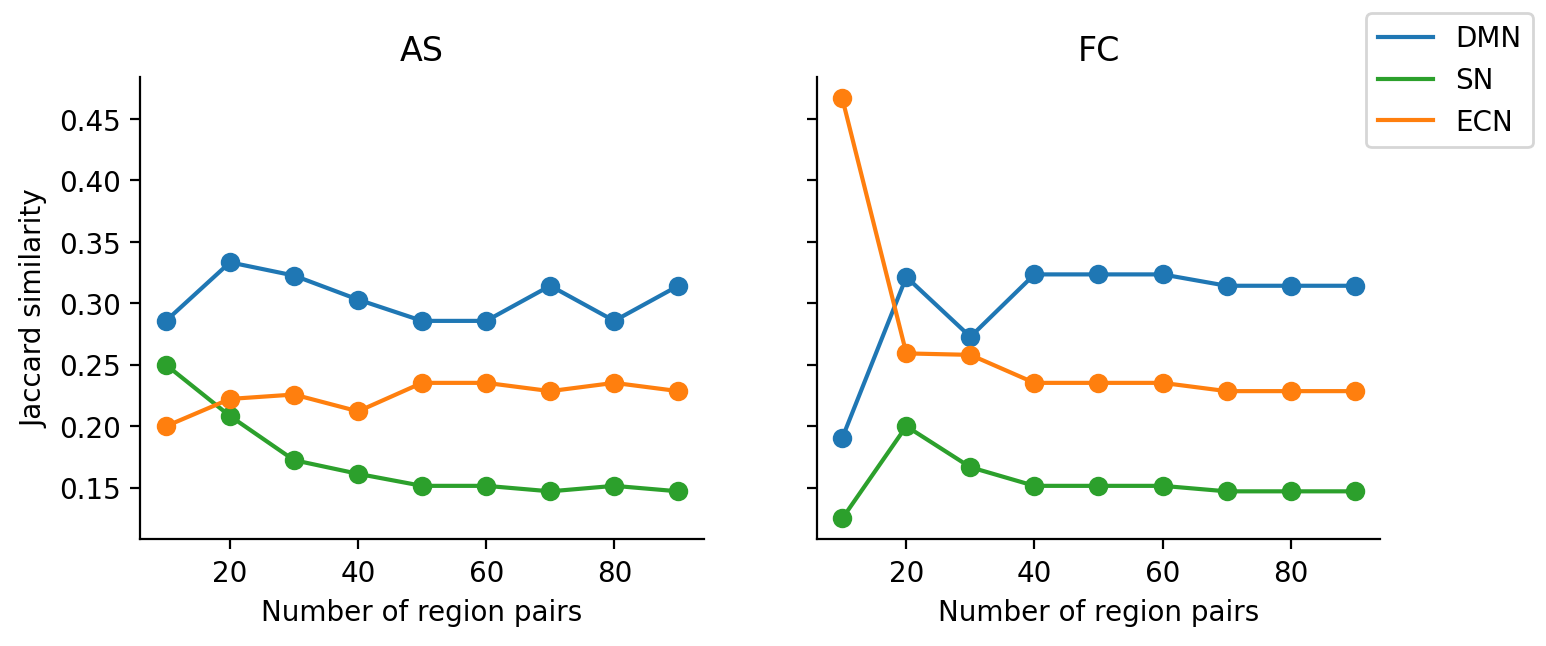

In [54]:
fig, ax = plt.subplots(1, 2, figsize = (8, 3), sharey = True, dpi = 200)
colors = {
    "J_DMN": "tab:blue", "with_DMN": "tab:blue",
    "J_SN": "tab:green", "with_SN": "tab:blue",
    "J_ECN": "tab:orange", "with_ECN": "tab:blue",
}

for col_id, matrix_name in enumerate(["AS", "FC"]):
    ca = ax[col_id]

    matrix = result[result["matrix"] == matrix_name]

    for network_to_plot in ["J_DMN", "J_SN", "J_ECN"]:
        ca.plot(matrix["k"], matrix[network_to_plot], label = network_to_plot.split("_")[1], color = colors[network_to_plot])
        ca.scatter(matrix["k"], matrix[network_to_plot], color = colors[network_to_plot])
    
    ca.spines[["top", "right"]].set_visible(False)
    ca.set_xlabel("Number of region pairs")
    ca.set_title(matrix_name)

ax[0].set_ylabel("Jaccard similarity")
fig.legend(*ca.get_legend_handles_labels())

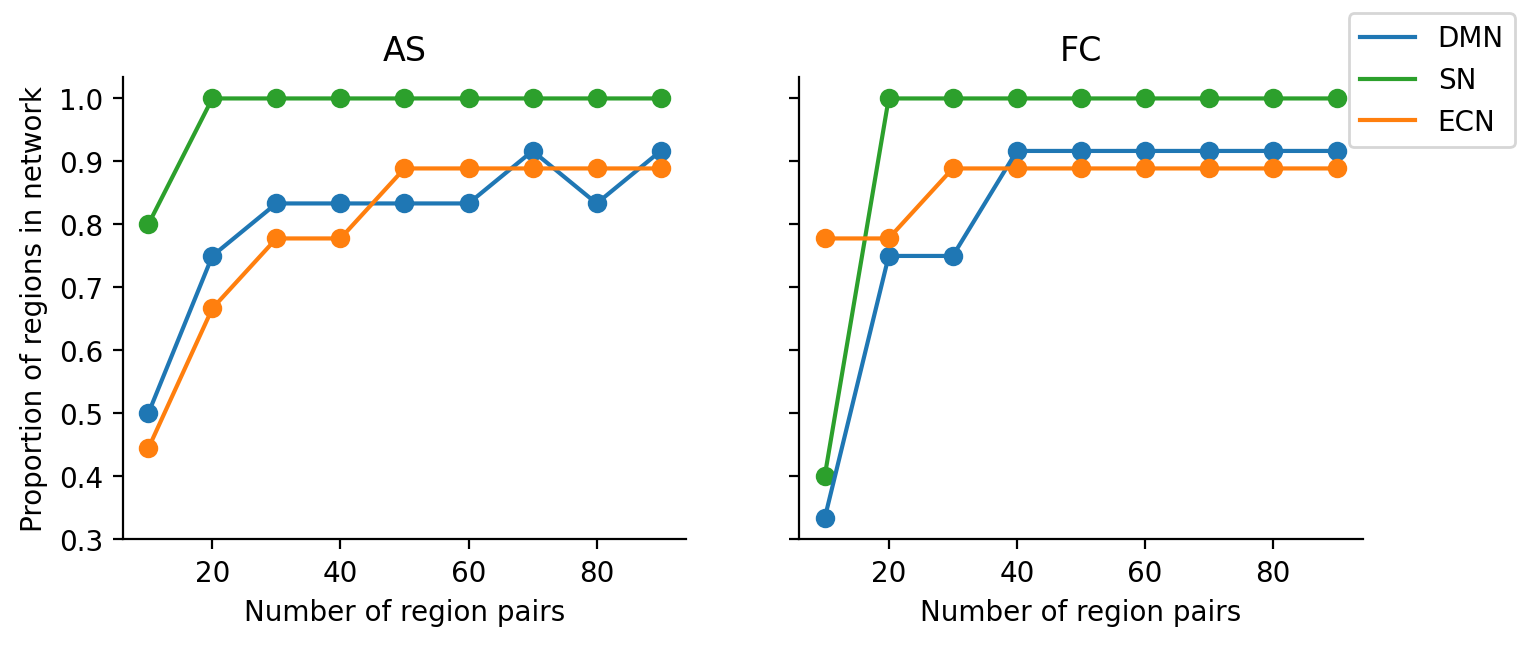

In [55]:
fig, ax = plt.subplots(1, 2, figsize = (8, 3), sharey = True, dpi = 200)
colors = {
    "J_DMN": "tab:blue", "with_DMN": "tab:blue",
    "J_SN": "tab:green", "with_SN": "tab:green",
    "J_ECN": "tab:orange", "with_ECN": "tab:orange",
}

for col_id, matrix_name in enumerate(["AS", "FC"]):
    ca = ax[col_id]

    matrix = result[result["matrix"] == matrix_name]

    for network_to_plot in ["with_DMN", "with_SN", "with_ECN"]:
        ca.plot(matrix["k"], matrix[network_to_plot], label = network_to_plot.split("_")[1], color = colors[network_to_plot])
        ca.scatter(matrix["k"], matrix[network_to_plot], color = colors[network_to_plot])
    
    ca.spines[["top", "right"]].set_visible(False)
    ca.set_xlabel("Number of region pairs")
    ca.set_title(matrix_name)

ax[0].set_ylabel("Proportion of regions in network")
fig.legend(*ca.get_legend_handles_labels())